**K-MEANS CLUSTERING**

Load & scale RFM data

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings; warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

rfm = pd.read_csv('../data/processed/rfm_scored.csv')
print(f"Loaded: {len(rfm):,} customers")
print(rfm[['Recency','Frequency','Monetary']].describe().round(1))

Loaded: 5,350 customers
       Recency  Frequency  Monetary
count   5350.0     5350.0    5350.0
mean     203.0        6.3    2689.6
std      210.0       12.0   11706.5
min        1.0        1.0       3.0
25%       26.0        1.0     330.2
50%       98.5        3.0     829.4
75%      382.0        7.0    2156.2
max      739.0      336.0  580987.0


In [2]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency','Frequency','Monetary']])

print(f"Scaled shape: {rfm_scaled.shape}")
print(f"Mean after scaling: {rfm_scaled.mean(axis=0).round(4)}")
print(f"Std after scaling:  {rfm_scaled.std(axis=0).round(4)}")

Scaled shape: (5350, 3)
Mean after scaling: [ 0. -0.  0.]
Std after scaling:  [1. 1. 1.]


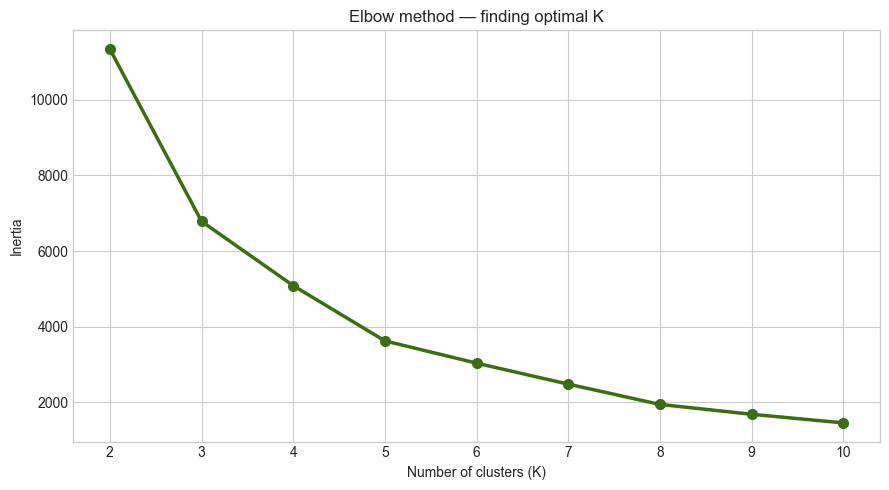

K=2: inertia=11338
K=3: inertia=6785
K=4: inertia=5085
K=5: inertia=3624
K=6: inertia=3036
K=7: inertia=2481
K=8: inertia=1945
K=9: inertia=1684
K=10: inertia=1456


In [3]:
inertia = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(9,5))
plt.plot(K_range, inertia, color='#3b6d11',
         linewidth=2.5, marker='o', markersize=7)
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow method — finding optimal K')
plt.xticks(K_range)
plt.tight_layout()
plt.savefig('../reports/figures/elbow_method.png', dpi=150)
plt.show()

for k, val in zip(K_range, inertia):
    print(f"K={k}: inertia={val:.0f}")

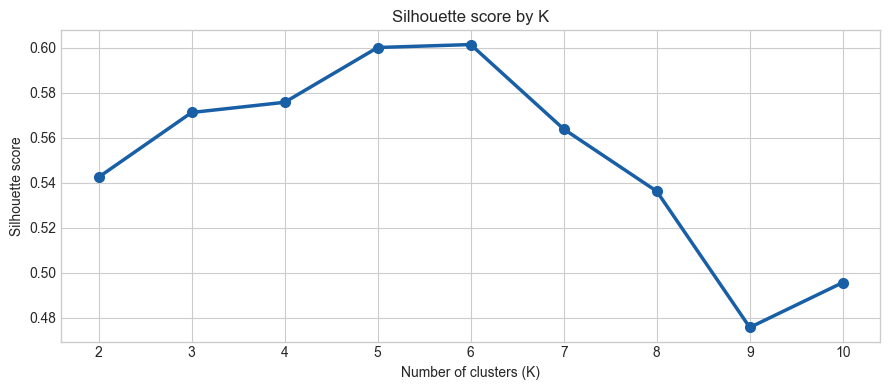

Best K by silhouette: 6 (score=0.6013)


In [8]:
sil_scores = []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    sil_scores.append(silhouette_score(rfm_scaled, labels))

plt.figure(figsize=(9,4))
plt.plot(K_range, sil_scores, color='#185fa5',
         linewidth=2.5, marker='o', markersize=7)
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette score')
plt.title('Silhouette score by K')
plt.tight_layout()
plt.savefig('../reports/figures/silhouette_scores.png', dpi=150)
plt.show()

best_k = K_range[sil_scores.index(max(sil_scores))]
print(f"Best K by silhouette: {best_k} (score={max(sil_scores):.4f})")

**Fit final K-Means model**

In [9]:
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print(f"Model trained ✅")
print(f"Silhouette Score: {silhouette_score(rfm_scaled, rfm['Cluster']):.4f}")
print(f"Cluster sizes:")
print(rfm['Cluster'].value_counts().sort_index().to_string())

Model trained ✅
Silhouette Score: 0.6013
Cluster sizes:
Cluster
0    1773
1    3255
2      13
3     302
4       6
5       1


In [10]:
cluster_profile = rfm.groupby('Cluster').agg(
    Count     = ('Customer ID', 'count'),
    Recency   = ('Recency',     'mean'),
    Frequency = ('Frequency',   'mean'),
    Monetary  = ('Monetary',    'mean')
).round(1)

print("Cluster profiles:")
print(cluster_profile.to_string())

Cluster profiles:
         Count  Recency  Frequency  Monetary
Cluster                                     
0         1773    470.5        2.2     678.7
1         3255     74.6        5.4    1830.8
2           13      9.2       82.1  130703.4
3          302     28.3       31.6   14950.4
4            6     63.3      217.5   71938.1
5            1      1.0      145.0  580987.0


In [11]:
cluster_labels = {
    0: 'Champions',
    1: 'Lost / Inactive',
    2: 'Mid-Value Customers',
    3: 'At-Risk'
}
rfm['Cluster_Label'] = rfm['Cluster'].map(cluster_labels)
print(rfm['Cluster_Label'].value_counts().to_string())

Cluster_Label
Lost / Inactive        3255
Champions              1773
At-Risk                 302
Mid-Value Customers      13


**Visualize clusters**

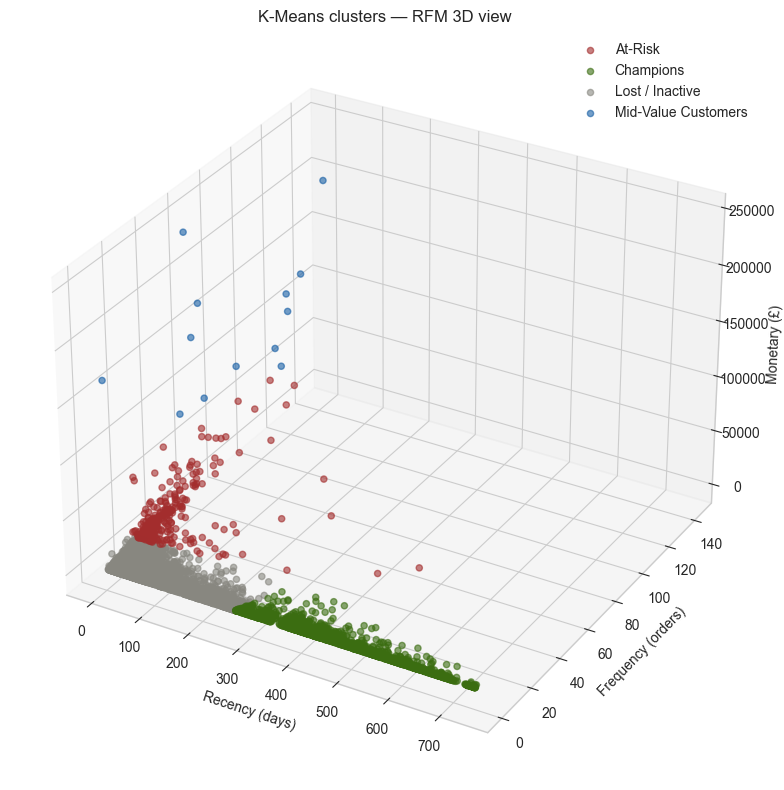

Saved ✅


In [12]:
from mpl_toolkits.mplot3d import Axes3D

colors = {'Champions':'#3b6d11','At-Risk':'#a32d2d',
          'Mid-Value Customers':'#185fa5','Lost / Inactive':'#888780'}

fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111, projection='3d')

for label, group in rfm.groupby('Cluster_Label'):
    ax.scatter(group['Recency'], group['Frequency'],
               group['Monetary'], c=colors[label],
               label=label, alpha=0.6, s=20)

ax.set_xlabel('Recency (days)')
ax.set_ylabel('Frequency (orders)')
ax.set_zlabel('Monetary (£)')
ax.set_title('K-Means clusters — RFM 3D view')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/kmeans_3d_scatter.png', dpi=150)
plt.show()
print("Saved ✅")

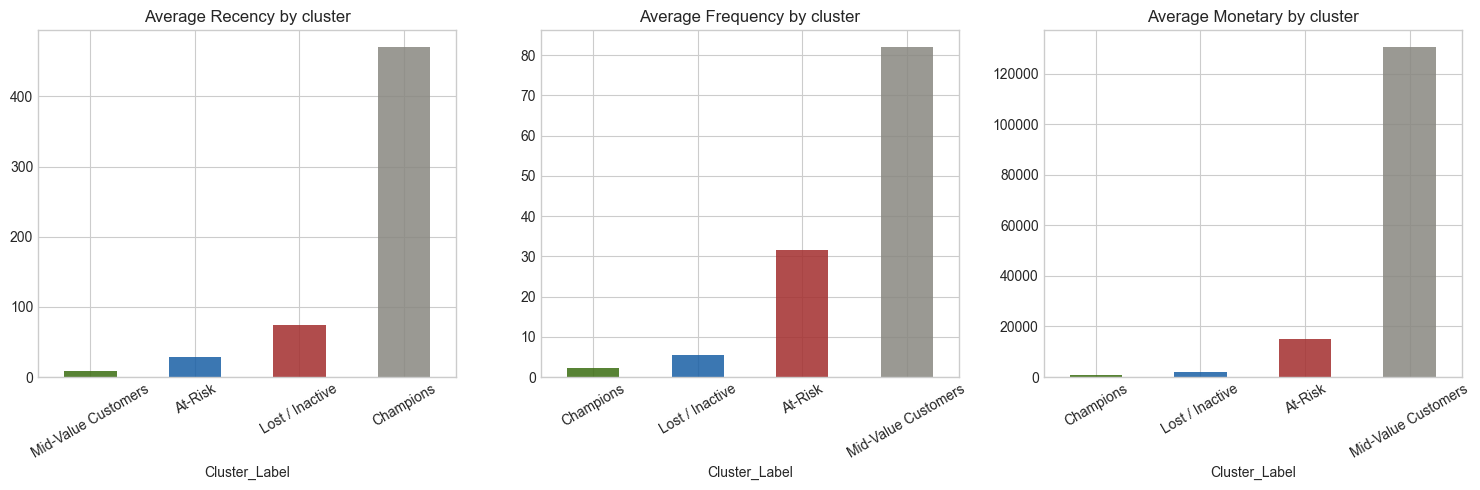

Saved ✅


In [13]:
fig, axes = plt.subplots(1,3,figsize=(15,5))

for i, col in enumerate(['Recency','Frequency','Monetary']):
    rfm.groupby('Cluster_Label')[col].mean().sort_values().plot(
        kind='bar', ax=axes[i],
        color=['#3b6d11','#185fa5','#a32d2d','#888780'],
        alpha=0.85)
    axes[i].set_title(f'Average {col} by cluster')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../reports/figures/cluster_profiles.png', dpi=150)
plt.show()
print("Saved ✅")

In [14]:
rfm.to_csv('../data/processed/rfm_clustered.csv', index=False)
print("rfm_clustered.csv saved ✅")
print(f"Shape: {rfm.shape}")
print(f"Columns: {rfm.columns.tolist()}")

rfm_clustered.csv saved ✅
Shape: (5350, 12)
Columns: ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'RFM_Total', 'Segment', 'Cluster', 'Cluster_Label']
